<a href="https://colab.research.google.com/github/sairamsrujan/celebal-excellence-internship/blob/main/Week4_RSaiRamSrujanKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification: ANN vs CNN

Comparing a plain ANN with a CNN on CIFAR-10 (60,000 32x32 colour images, 10 classes), then
improving the CNN with deeper layers, batch norm, longer training, early stopping and augmentation.

## 1. Setup

Imports, a fixed random seed, and a dict to store each model's test score.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # quieten TensorFlow's startup logs

import random
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# fix the seeds so results don't change on every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
%matplotlib inline

results = {}   # collect each model's test score here for the final table

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load the data

CIFAR-10 from Keras: 50,000 training and 10,000 test images.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)
print("Pixel values range from", x_train.min(), "to", x_train.max())

Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)
Pixel values range from 0 to 255


### Sample images

Quick check that the images and labels line up.

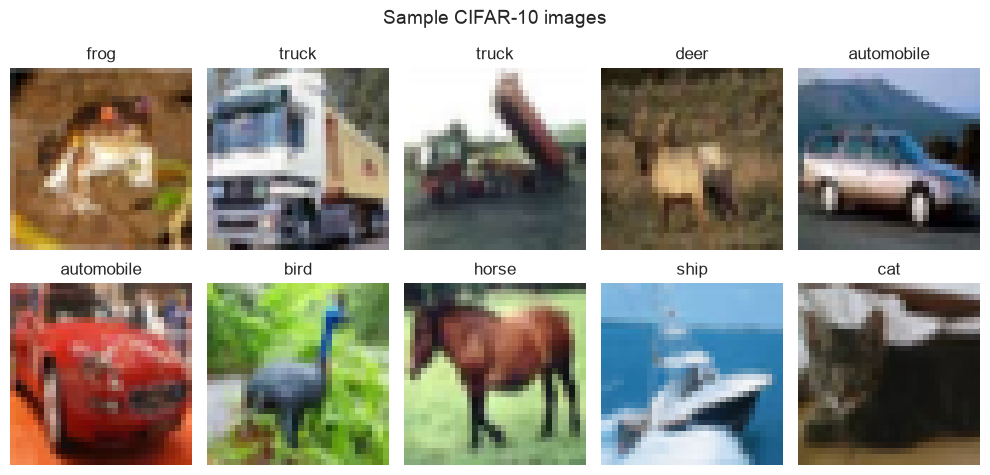

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Scale pixels to 0-1, and flatten the images to length-3072 vectors for the ANN.

In [ ]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# the ANN needs flat vectors instead of images
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("CNN input shape:", x_train_norm.shape[1:])
print("ANN input shape:", x_train_flat.shape[1:])

CNN input shape: (32, 32, 3)
ANN input shape: (3072,)


## 4. ANN model

Fully connected network on the flattened images. 10 epochs, Adam, sparse categorical crossentropy.

In [ ]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name="ANN_Baseline")

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
ann_model.summary()

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=2,
)

Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

...

704/704 - 3s - 4ms/step - accuracy: 0.3792 - loss: 1.7067 - val_accuracy: 0.3976 - val_loss: 1.6841


Epoch 9/10


704/704 - 3s - 4ms/step - accuracy: 0.3864 - loss: 1.6886 - val_accuracy: 0.4224 - val_loss: 1.6458


Epoch 10/10


704/704 - 2s - 4ms/step - accuracy: 0.3925 - loss: 1.6755 - val_accuracy: 0.4166 - val_loss: 1.6657


In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN test accuracy: {ann_test_acc:.4f}  (loss {ann_test_loss:.4f})")

results["ANN (baseline)"] = {
    "test_acc": ann_test_acc, "test_loss": ann_test_loss,
    "params": ann_model.count_params(), "epochs": len(ann_history.history['loss']),
    "history": ann_history, "model": ann_model, "x_eval": x_test_flat,
}

ANN test accuracy: 0.4100  (loss 1.6568)


## 5. CNN model

Three conv blocks (32, 64, 128 filters) with batch norm and max pooling, then a dense classifier.
Same training setup as the ANN.

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name="CNN_Baseline")

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=2,
)

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

...

704/704 - 9s - 13ms/step - accuracy: 0.8080 - loss: 0.5428 - val_accuracy: 0.6810 - val_loss: 1.0352


Epoch 9/10


704/704 - 9s - 13ms/step - accuracy: 0.8250 - loss: 0.4846 - val_accuracy: 0.6614 - val_loss: 1.1779


Epoch 10/10


704/704 - 10s - 14ms/step - accuracy: 0.8429 - loss: 0.4359 - val_accuracy: 0.6348 - val_loss: 1.4183


In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN test accuracy: {cnn_test_acc:.4f}  (loss {cnn_test_loss:.4f})")

results["CNN (baseline)"] = {
    "test_acc": cnn_test_acc, "test_loss": cnn_test_loss,
    "params": cnn_model.count_params(), "epochs": len(cnn_history.history['loss']),
    "history": cnn_history, "model": cnn_model, "x_eval": x_test_norm,
}

CNN test accuracy: 0.6207  (loss 1.5021)


## 6. ANN vs CNN

Validation accuracy and loss for both models over the 10 epochs.

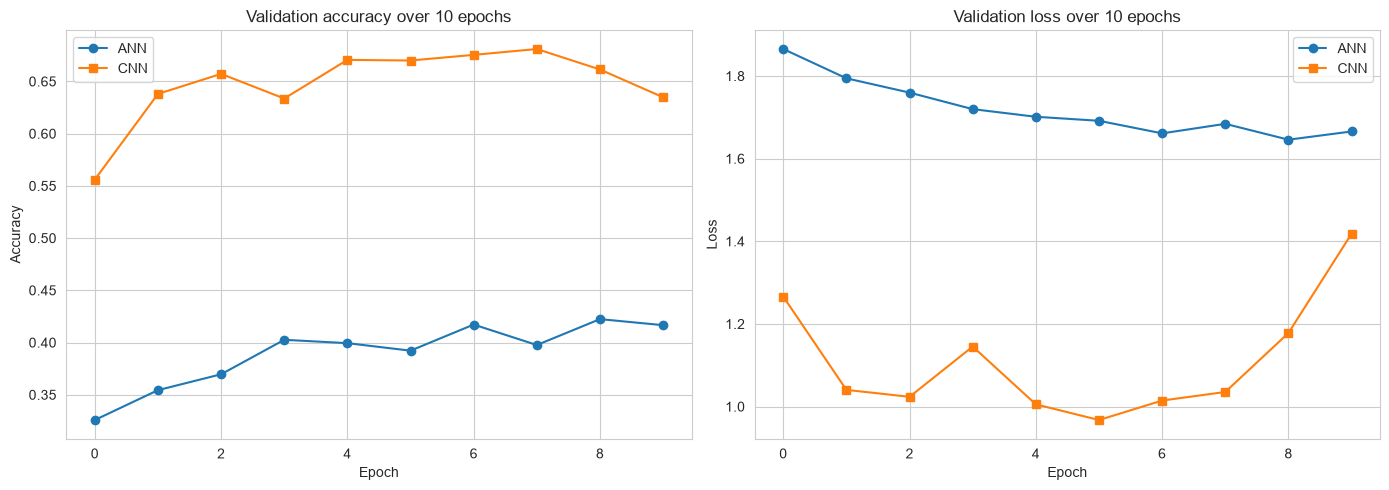

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['val_accuracy'], 'o-', label='ANN')
axes[0].plot(cnn_history.history['val_accuracy'], 's-', label='CNN')
axes[0].set_title("Validation accuracy over 10 epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(ann_history.history['val_loss'], 'o-', label='ANN')
axes[1].plot(cnn_history.history['val_loss'], 's-', label='CNN')
axes[1].set_title("Validation loss over 10 epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Data augmentation

Random flip, rotation and zoom applied during training to reduce overfitting.

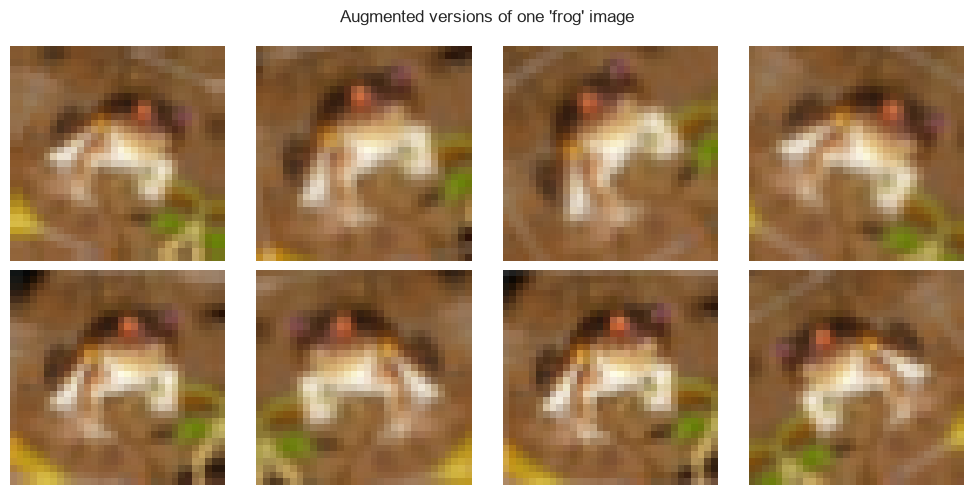

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# show the same image augmented a few different ways
plt.figure(figsize=(10, 5))
sample = x_train_norm[0:1]
for i in range(8):
    aug = data_augmentation(sample, training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(aug[0], 0, 1))
    plt.axis("off")
plt.suptitle(f"Augmented versions of one '{class_names[int(y_train[0][0])]}' image")
plt.tight_layout()
plt.show()

Augmentation goes in as the first layers of the CNN. Built here, trained in Task 5.

In [ ]:
aug_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax'),
], name="Augmented_CNN")

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
aug_cnn_model.summary()

Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 8. Student tasks

1. More layers in the ANN
2. Scale CNN filters (32, 64, 128)
3. Train for 20 epochs
4. Add EarlyStopping
5. Train with augmentation

Shared settings below: 20 epochs and a fresh EarlyStopping per model (tasks 3 and 4).

In [ ]:
EPOCHS = 20

# make a new EarlyStopping for each model; a fresh one each time keeps the
# "best score" from one model from leaking into the next
def make_early_stopping():
    return EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Improved models train for up to", EPOCHS, "epochs, with EarlyStopping (patience=5).")

Improved models train for up to 20 epochs, with EarlyStopping (patience=5).


### Task 1: More ANN layers

Deeper ANN (1024, 512, 256, 128) with batch norm and dropout.

In [ ]:
ann_enhanced = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name="ANN_Enhanced")

ann_enhanced.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

ann_enh_history = ann_enhanced.fit(
    x_train_flat, y_train,
    epochs=EPOCHS, validation_split=0.1, batch_size=128,
    callbacks=[make_early_stopping()], verbose=2,
)

ann_enh_loss, ann_enh_acc = ann_enhanced.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nEnhanced ANN test accuracy: {ann_enh_acc:.4f}")

results["ANN (enhanced)"] = {
    "test_acc": ann_enh_acc, "test_loss": ann_enh_loss,
    "params": ann_enhanced.count_params(), "epochs": len(ann_enh_history.history['loss']),
    "history": ann_enh_history, "model": ann_enhanced, "x_eval": x_test_flat,
}

Epoch 1/20


352/352 - 5s - 13ms/step - accuracy: 0.3137 - loss: 1.9080 - val_accuracy: 0.3340 - val_loss: 1.8474


Epoch 2/20


352/352 - 5s - 13ms/step - accuracy: 0.3809 - loss: 1.7203 - val_accuracy: 0.3774 - val_loss: 1.7399


Epoch 3/20


...

Epoch 19/20


352/352 - 5s - 15ms/step - accuracy: 0.4599 - loss: 1.5025 - val_accuracy: 0.5024 - val_loss: 1.4174


Epoch 20/20


352/352 - 6s - 18ms/step - accuracy: 0.4613 - loss: 1.5016 - val_accuracy: 0.4838 - val_loss: 1.4626



Enhanced ANN test accuracy: 0.5012


### Task 2: Scale CNN filters (32, 64, 128)

Deeper CNN in three blocks with dropout and a bigger dense layer. Best model here.

In [ ]:
cnn_enhanced = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # block 1: 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 2: 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # block 3: 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name="CNN_Enhanced")

cnn_enhanced.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
cnn_enhanced.summary()

cnn_enh_history = cnn_enhanced.fit(
    x_train_norm, y_train,
    epochs=EPOCHS, validation_split=0.1, batch_size=128,
    callbacks=[make_early_stopping()], verbose=2,
)

cnn_enh_loss, cnn_enh_acc = cnn_enhanced.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nEnhanced CNN test accuracy: {cnn_enh_acc:.4f}")

results["CNN (enhanced)"] = {
    "test_acc": cnn_enh_acc, "test_loss": cnn_enh_loss,
    "params": cnn_enhanced.count_params(), "epochs": len(cnn_enh_history.history['loss']),
    "history": cnn_enh_history, "model": cnn_enhanced, "x_eval": x_test_norm,
}

Model: "CNN_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

...

Epoch 19/20


352/352 - 23s - 66ms/step - accuracy: 0.7756 - loss: 0.6385 - val_accuracy: 0.7704 - val_loss: 0.6665


Epoch 20/20


352/352 - 24s - 68ms/step - accuracy: 0.7808 - loss: 0.6231 - val_accuracy: 0.7392 - val_loss: 0.7331



Enhanced CNN test accuracy: 0.7754


### Task 3: 20 epochs

The improved models train for up to 20 epochs (with early stopping).

In [ ]:
print("EPOCHS =", EPOCHS)
print("Actual epochs each model ran (EarlyStopping can stop sooner):")
for name in ["ANN (enhanced)", "CNN (enhanced)"]:
    if name in results:
        print(f"  {name}: {results[name]['epochs']} epochs")

EPOCHS = 20
Actual epochs each model ran (EarlyStopping can stop sooner):
  ANN (enhanced): 20 epochs
  CNN (enhanced): 20 epochs


### Task 4: EarlyStopping

Stops on val_loss (patience 5) and restores the best weights. A new callback for each model.

In [ ]:
es = make_early_stopping()
print("EarlyStopping settings:")
print("  monitor              =", es.monitor)
print("  patience             =", es.patience)
print("  restore_best_weights =", es.restore_best_weights)

EarlyStopping settings:
  monitor              = val_loss
  patience             = 5
  restore_best_weights = True


### Task 5: Augmentation training

Train the augmented CNN for up to 20 epochs.

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=EPOCHS, validation_split=0.1, batch_size=128,
    callbacks=[make_early_stopping()], verbose=2,
)

aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAugmented CNN test accuracy: {aug_acc:.4f}")

results["CNN (augmented)"] = {
    "test_acc": aug_acc, "test_loss": aug_loss,
    "params": aug_cnn_model.count_params(), "epochs": len(aug_history.history['loss']),
    "history": aug_history, "model": aug_cnn_model, "x_eval": x_test_norm,
}

Epoch 1/20


352/352 - 24s - 68ms/step - accuracy: 0.3769 - loss: 1.7514 - val_accuracy: 0.2638 - val_loss: 2.6754


Epoch 2/20


352/352 - 21s - 59ms/step - accuracy: 0.4784 - loss: 1.4562 - val_accuracy: 0.5800 - val_loss: 1.1734


Epoch 3/20


...

Epoch 18/20


352/352 - 20s - 57ms/step - accuracy: 0.7251 - loss: 0.8022 - val_accuracy: 0.7240 - val_loss: 0.8089


Epoch 19/20


352/352 - 22s - 63ms/step - accuracy: 0.7277 - loss: 0.7898 - val_accuracy: 0.7340 - val_loss: 0.7721



Augmented CNN test accuracy: 0.7323


## 9. Best model

Training curves, confusion matrix, classification report and per-class accuracy for the top model.

Best model: CNN (enhanced)  (test accuracy 0.7754)


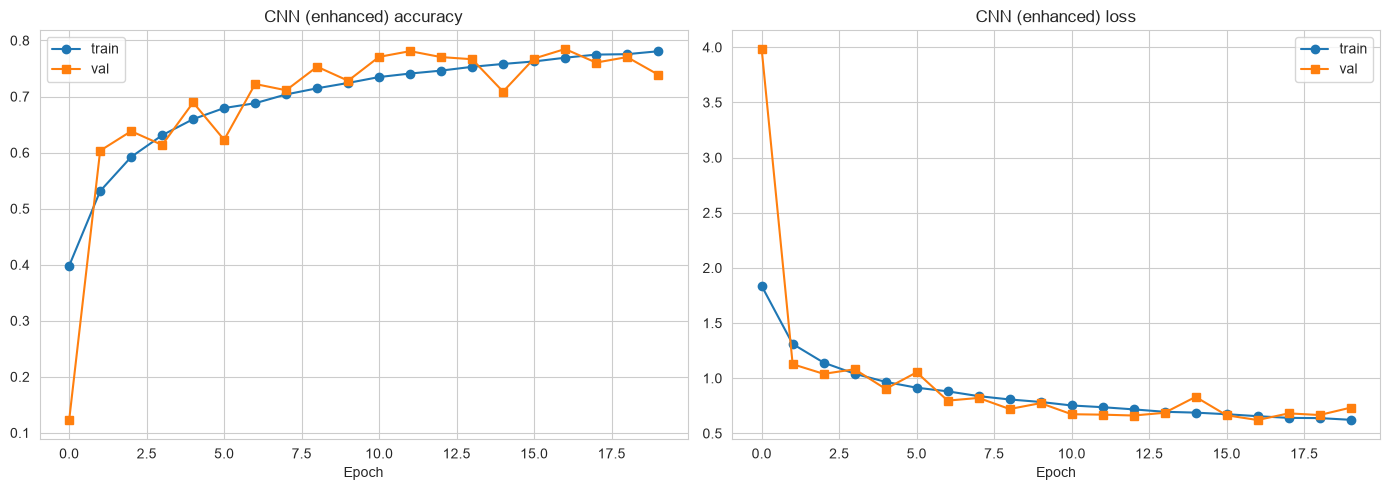

In [ ]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]
print(f"Best model: {best_name}  (test accuracy {best['test_acc']:.4f})")

h = best['history'].history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['accuracy'], 'o-', label='train')
axes[0].plot(h['val_accuracy'], 's-', label='val')
axes[0].set_title(f"{best_name} accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(h['loss'], 'o-', label='train')
axes[1].plot(h['val_loss'], 's-', label='val')
axes[1].set_title(f"{best_name} loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

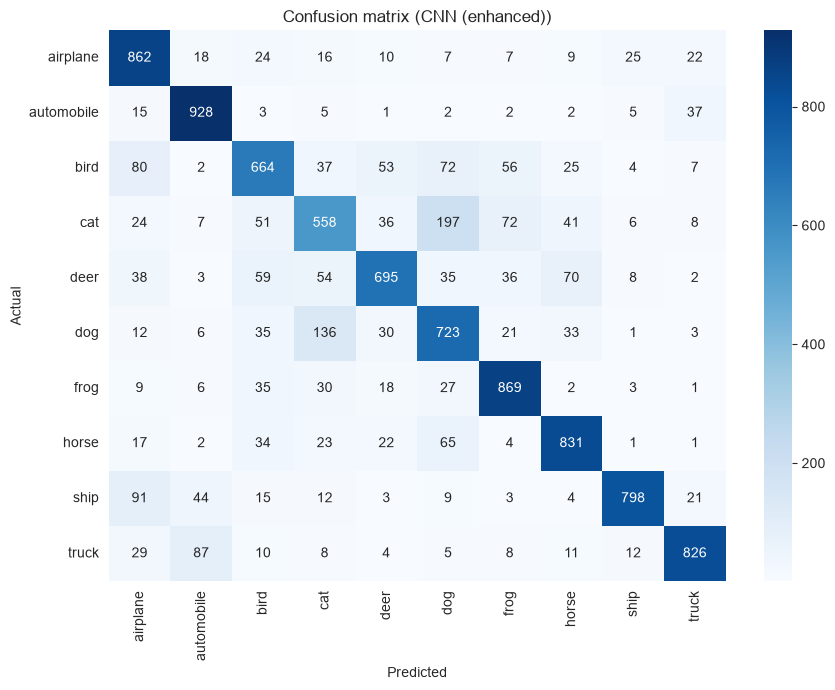

Classification report:
              precision    recall  f1-score   support

    airplane      0.732     0.862     0.792      1000
  automobile      0.841     0.928     0.883      1000
        bird      0.714     0.664     0.688      1000
         cat      0.635     0.558     0.594      1000
        deer      0.797     0.695     0.743      1000
         dog      0.633     0.723     0.675      1000
        frog      0.806     0.869     0.836      1000
       horse      0.808     0.831     0.820      1000
        ship      0.925     0.798     0.857      1000
       truck      0.890     0.826     0.857      1000

    accuracy                          0.775     10000
   macro avg      0.778     0.775     0.774     10000
weighted avg      0.778     0.775     0.774     10000



In [ ]:
y_true = y_test.flatten()
y_pred = np.argmax(best['model'].predict(best['x_eval'], verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion matrix ({best_name})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

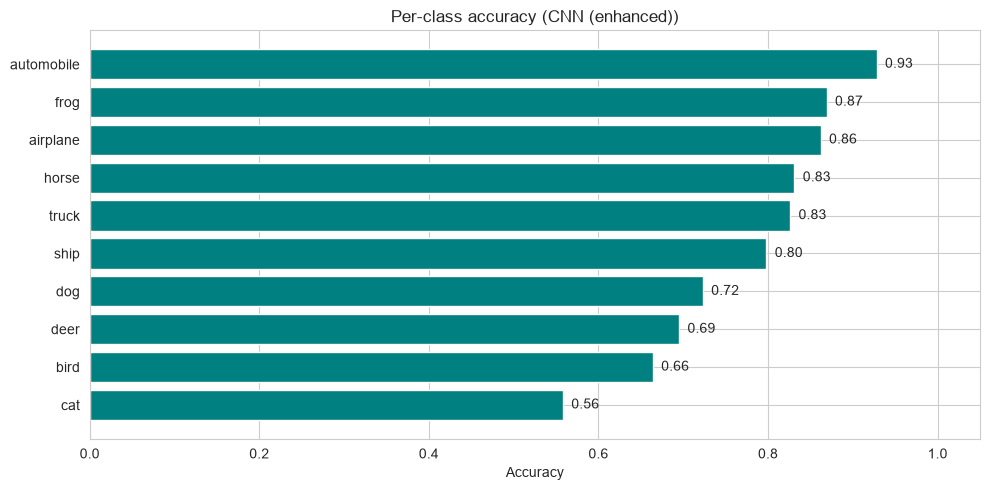

Easiest class: automobile (0.93)
Hardest class: cat (0.56)


In [ ]:
# per-class accuracy = correct predictions / total images in that class
per_class_acc = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class_acc)

plt.figure(figsize=(10, 5))
plt.barh([class_names[i] for i in order], per_class_acc[order], color='teal')
for i, v in enumerate(per_class_acc[order]):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center')
plt.xlabel("Accuracy"); plt.xlim(0, 1.05)
plt.title(f"Per-class accuracy ({best_name})")
plt.tight_layout(); plt.show()

print("Easiest class:", class_names[order[-1]], f"({per_class_acc[order[-1]]:.2f})")
print("Hardest class:", class_names[order[0]],  f"({per_class_acc[order[0]]:.2f})")

### Observations

- The CNNs clearly beat the ANN.
- Vehicles are the easiest classes; similar animals (cat/dog, deer/horse) get confused most.
- Batch norm, dropout and more filters help; augmentation keeps train and validation closer.

## 10. Results

Test accuracy for all five models, sorted, with a bar chart.

In [ ]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Test Accuracy": round(r["test_acc"], 4),
        "Test Loss": round(r["test_loss"], 4),
        "Parameters": r["params"],
        "Epochs Run": r["epochs"],
    }
    for name, r in results.items()
]).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

styled = (comparison.style
          .background_gradient(subset=["Test Accuracy"], cmap="Greens")
          .format({"Test Accuracy": "{:.4f}", "Test Loss": "{:.4f}",
                   "Parameters": "{:,}"}))
display(styled)

,Model,Test Accuracy,Test Loss,Parameters,Epochs Run
0,CNN (enhanced),0.7754,0.6441,"622,282",20
1,CNN (augmented),0.7323,0.7718,"357,706",19
2,CNN (baseline),0.6207,1.5021,"357,194",10
3,ANN (enhanced),0.5012,1.4057,"3,843,210",20
4,ANN (baseline),0.4100,1.6568,"1,707,274",10


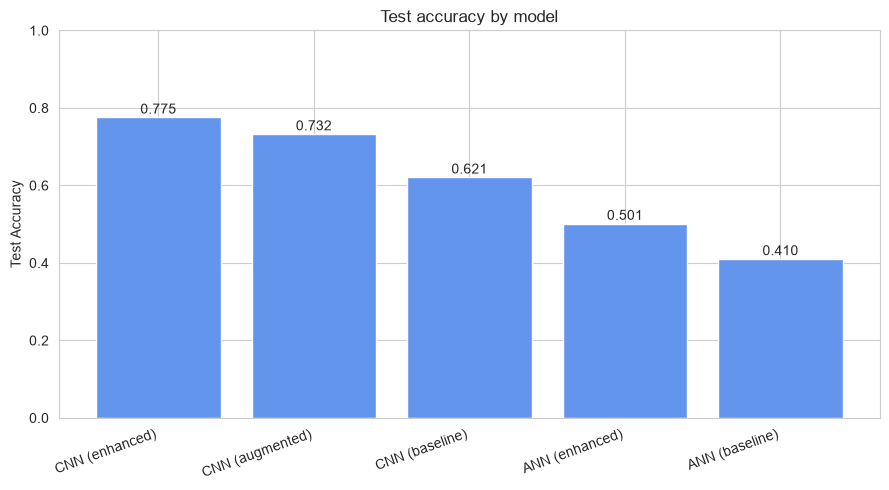

,Model,Test Accuracy,Test Loss,Parameters,Epochs Run
0,CNN (enhanced),0.7754,0.6441,622282,20
1,CNN (augmented),0.7323,0.7718,357706,19
2,CNN (baseline),0.6207,1.5021,357194,10
3,ANN (enhanced),0.5012,1.4057,3843210,20
4,ANN (baseline),0.4100,1.6568,1707274,10


In [ ]:
plt.figure(figsize=(9, 5))
bars = plt.bar(comparison["Model"], comparison["Test Accuracy"], color='cornflowerblue')
for b, v in zip(bars, comparison["Test Accuracy"]):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha='center')
plt.ylabel("Test Accuracy"); plt.ylim(0, 1)
plt.title("Test accuracy by model")
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

comparison

## 11. Conclusion

This notebook compared a fully connected network (ANN) with a CNN on CIFAR-10, and then looked at
how far a few standard training strategies could push the CNN.

The clearest result is that architecture matters more than raw size. The baseline CNN reached
about 62% test accuracy with roughly 357k parameters, while the enhanced ANN only reached about
50% even though it had around 3.8M parameters. Because the ANN works on flattened pixels, the
extra capacity cannot make up for the spatial information it throws away. The CNN keeps that
information through convolution and pooling, so it learns the task far more efficiently.

Adding common training strategies took the CNN from about 62% to about 77% test accuracy. Scaling
the filters to 32, 64, 128, adding batch normalization and dropout, training for 20 epochs, and
using early stopping all contributed. Data augmentation gave a similar jump on a simpler CNN
(about 73%) and, just as importantly, kept the training and validation curves close together,
which is a sign of less overfitting.

The per-class results follow the usual CIFAR-10 pattern. The vehicle classes (automobile, truck,
ship, airplane) were the easiest, while the visually similar animals were the hardest. Cat was
the weakest class, at about 56% recall, and was most often confused with dog.

There is still room to improve. A deeper or residual architecture, a learning rate schedule, or
stronger augmentation would likely push the accuracy higher. For the goal of this notebook,
comparing the ANN and CNN and measuring the effect of each training strategy, the results above
make the differences clear.